##  student's `math_score Overview USING REGRESSOR

This notebook builds and evaluates regression models to predict a student's `math_score` from the other features in the dataset. It follows on from the EDA notebook and covers this workflow:

**1. Setup**
- Import data-handling/plotting libraries (`numpy`, `pandas`, `matplotlib`, `seaborn`).
- Import modeling tools: evaluation metrics, 9 regression algorithms (Linear Regression, Lasso, Ridge, K-Neighbors, Decision Tree, Random Forest, AdaBoost, SVR, XGBoost, CatBoost), and `RandomizedSearchCV` for tuning.

**2. Data Loading**
- Reload the same `data/stud.csv` dataset used in the EDA notebook into `df`.
- Preview it with `df.head()`.

**3. Feature/Target Split**
- Build `X` by dropping `math_score` from `df` — the remaining 7 columns (5 categorical + `reading_score` + `writing_score`) are the model inputs.
- Build `y = df['math_score']` — the value being predicted.
- Re-check each categorical column's unique values, confirming exactly which labels need encoding.

**4. Preprocessing Pipeline**
- Split `X`'s columns into `num_features` (numeric) and `cat_features` (categorical) via `select_dtypes`.
- Build a `ColumnTransformer` (`preprocessor`) that applies `OneHotEncoder` to categorical columns and `StandardScaler` to numeric columns.
- Apply it with `preprocessor.fit_transform(X)`, expanding the original 7 columns into 19 model-ready numeric columns.

**5. Train/Test Split**
- `train_test_split(X, y, test_size=0.2, random_state=42)` — 80% train (800 rows) / 20% test (200 rows).

**6. Evaluation Helper**
- Define `evaluate_model(true, predicted)`, returning MAE, RMSE, and R² — used consistently to score every model.

**7. Train & Compare Multiple Models**
- Define a dictionary of 9 candidate regressors.
- Loop through each: fit on training data, predict on both train and test sets, print training vs. test metrics (to spot overfitting), and record each model's name and test R² in `model_list`/`r2_list`.

**8. Leaderboard**
- Build a DataFrame from `model_list`/`r2_list`, sorted by test R² descending, to rank all 9 models by generalization performance. (Ridge and Linear Regression came out on top, with the gap between them being negligible.)

**9. Finalize a Model**
- Refit a standalone `LinearRegression` model, predict on the test set, and report accuracy (R² as a percentage, ~88%).

**10. Diagnostics**
- Scatter plot of actual vs. predicted test values.
- `sns.regplot` overlaying a regression line on the same actual-vs-predicted data (no CI band) to visually assess fit quality and bias.
- A `pred_df` DataFrame listing actual value, predicted value, and the difference per test sample, for inspecting individual prediction errors.

**11. Test with a New Sample**
- Construct a single-row DataFrame representing a hypothetical new student, transform it with the already-fitted `preprocessor`, and predict its math score with `lin_model` — demonstrating how the trained pipeline would be used on unseen, real-world input.

**Purpose of this workflow:** take the cleaned, explored dataset from the EDA notebook, engineer it into a model-ready form, systematically compare multiple regression algorithms under identical conditions, select and finalize the best-performing one, and validate/demonstrate its predictions both in aggregate (metrics, plots) and on an individual new sample.

## Model Training

#### 1.1 Import Data and Required Packages
##### Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

**What this cell does:** Imports every library needed for modeling — `numpy`/`pandas` for data handling, `matplotlib`/`seaborn` for plotting, evaluation metrics (`mean_squared_error`, `r2_score`) from scikit-learn, a set of regression algorithms (`KNeighborsRegressor`, `DecisionTreeRegressor`, `RandomForestRegressor`, `AdaBoostRegressor`, `SVR`, `LinearRegression`, `Ridge`, `Lasso`), `RandomizedSearchCV` for hyperparameter tuning, and the gradient-boosting libraries `CatBoostRegressor` and `XGBRegressor`. `warnings` is imported to be silenced later.

In [1]:
# Import catboost FIRST, before numpy/pandas/matplotlib/sklearn -
# loading its large native DLL after those libraries are already in memory
# was causing 'ImportError: DLL load failed ... Not enough memory resources'
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
import warnings

In [2]:
#pip install catBoost

In [3]:
df = pd.read_csv(r'C:\Users\satya\Documents\udemy_datascience and deeplearning\mlproject\notebook\data\stud.csv')

#### Show Top 5 Records

**What this cell does:** Calls `df.head()` to preview the first 5 rows of the dataset before building the feature matrix and target variable.

In [4]:
df.head()


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Preparing X and Y variables

**What this cell does:** Creates the feature matrix `X` by dropping the `math_score` column from `df` — `math_score` is the value the model will be trained to predict, so it is excluded from the inputs.

In [5]:
X = df.drop('math_score', axis=1)

**What this cell does:** Calls `X.head()` to confirm that the feature matrix contains all columns except `math_score` — the demographic/categorical columns plus `reading_score` and `writing_score`.

In [6]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


**What this cell does:** Prints the unique category values for each categorical column (`gender`, `race_ethnicity`, `parental_level_of_education`, `lunch`, `test_preparation_course`), the same check performed in the EDA notebook, to confirm the exact labels that will need to be one-hot encoded.

In [7]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:      ['female' 'male']
Categories in 'race_ethnicity' variable:   ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:      ['standard' 'free/reduced']
Categories in 'test preparation course' variable:      ['none' 'completed']


**What this cell does:** Defines the target variable `y` as the `math_score` column — this is the value the regression models will learn to predict from the other features.

In [8]:
y =df['math_score']

**What this cell does:** Displays the `y` Series to show a sample of the target values (math scores) and confirm its shape and dtype.

In [9]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [10]:
import pandas as pd
pd.DataFrame(y)

,math_score
0,72
1,69
2,90
3,47
4,76
...,...
995,88
996,62
997,59
998,68


**What this cell does:** Builds the preprocessing pipeline: separates `X`'s columns into `num_features` (numeric) and `cat_features` (categorical) using `select_dtypes`, then constructs a `ColumnTransformer` named `preprocessor` that applies `OneHotEncoder` to the categorical columns and `StandardScaler` to the numeric columns, so both feature types are properly encoded/scaled before modeling.

**Detailed explanation:**

- `num_features = X.select_dtypes(exclude="object").columns` — selects every column in `X` whose dtype is NOT `object` (i.e., the numeric columns: `reading_score`, `writing_score`), returning their column names.
- `cat_features = X.select_dtypes(include="object").columns` — selects every column whose dtype IS `object` (the categorical columns: `gender`, `race_ethnicity`, `parental_level_of_education`, `lunch`, `test_preparation_course`), returning their column names.
- `from sklearn.preprocessing import OneHotEncoder, StandardScaler` — imports the two transformers needed: `OneHotEncoder` converts categorical text values into binary indicator columns; `StandardScaler` rescales numeric values to zero mean and unit variance.
- `from sklearn.compose import ColumnTransformer` — imports the tool that lets different transformations be applied to different columns of the same DataFrame in one step.
- `numeric_transformer = StandardScaler()` — creates a scaler instance that will standardize numeric features (subtract mean, divide by std dev), which helps distance-based and gradient-based models perform better.
- `oh_transformer = OneHotEncoder()` — creates a one-hot encoder instance that will convert each categorical column's values into a set of 0/1 columns (one per category), since models can't work with raw text.
- `preprocessor = ColumnTransformer([...])` — builds the combined preprocessing object. It's defined as a list of `(name, transformer, columns)` tuples:
  - `("OneHotEncoder", oh_transformer, cat_features)` — applies one-hot encoding to the categorical columns.
  - `("StandardScaler", numeric_transformer, num_features)` — applies standard scaling to the numeric columns.
  - When later called with `.fit_transform(X)`, `ColumnTransformer` runs both transformations on their respective columns and concatenates the results into a single output array — so all 7 original feature columns become one unified, model-ready numeric matrix.

**Purpose:** prepares `X` for machine learning by converting categorical text into numeric indicator columns and putting numeric columns on a comparable scale, both in a single reusable transformer object (`preprocessor`) that can later be applied consistently to training and test data (and eventually to new, unseen data).

In [11]:
# Create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),
    ]
)

**What this cell does:** Applies the `preprocessor` to `X` via `fit_transform`, replacing the raw feature matrix with its one-hot-encoded and scaled numeric form, ready to feed into scikit-learn models.

In [12]:
X = preprocessor.fit_transform(X)

**What this cell does:** Calls `X.shape` on the transformed feature matrix to confirm how many columns the encoding produced (expanded from the original categorical/numeric columns into one-hot + scaled numeric columns).

In [13]:
X.shape

(1000, 19)

In [14]:
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.193999,0.391492
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.427476,1.313269
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.770109,1.642475
3,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-0.833899,-1.583744
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.605158,0.457333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,2.044215,1.774157
996,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-0.970952,-0.859491
997,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.125472,-0.201079
998,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.605158,0.589015


**What this cell does:** Splits the transformed data into training and test sets using `train_test_split` (80% train / 20% test, `random_state=42` for reproducibility), then prints the shapes of `X_train` and `X_test` to confirm the split sizes.

In [15]:
# separate dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((800, 19), (200, 19))

#### Create an Evaluate Function to give all metrics after model Training

**What this cell does:** Defines a helper function `evaluate_model(true, predicted)` that computes and returns three regression metrics — Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score — so every model below can be scored consistently with one function call.

In [16]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

**What this cell does:** Defines a dictionary of nine candidate regression models (Linear Regression, Lasso, Ridge, K-Neighbors, Decision Tree, Random Forest, XGBoost, CatBoost, AdaBoost), then loops over each one to: fit it on `X_train`/`y_train`, predict on both the training and test sets, evaluate both sets with `evaluate_model`, print the training and test metrics for comparison, and store each model's name and test R² score in `model_list`/`r2_list` for later ranking.

**Detailed explanation:**

- `models = {...}` — a dictionary mapping a human-readable model name (string) to an instantiated (but not yet trained) scikit-learn/xgboost/catboost regressor object. 9 candidate algorithms are defined, covering linear models (Linear Regression, Lasso, Ridge), a distance-based model (K-Neighbors), tree-based models (Decision Tree, Random Forest), and boosting ensembles (XGBoost, CatBoost, AdaBoost). `CatBoostRegressor(verbose=False)` suppresses CatBoost's default per-iteration training log.
- `model_list = []` / `r2_list = []` — empty lists that will collect, respectively, each model's name and its test-set R² score, for building a leaderboard afterward.
- `for i in range(len(list(models))):` — loops over the models by numeric index (0 through 8).
- `model = list(models.values())[i]` — converts the dict's values to a list and grabs the i-th model object.
- `model.fit(X_train, y_train)` — trains that model on the preprocessed training features and the training targets (math scores).
- `y_train_pred = model.predict(X_train)` / `y_test_pred = model.predict(X_test)` — generates predictions on both the training set (to check for overfitting) and the test set (to check generalization to unseen data).
- `model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)` — calls the earlier-defined helper to compute MAE, RMSE, and R² comparing actual vs. predicted training values.
- `model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)` — same three metrics, but for the test set — this is the number that matters for judging real-world performance.
- `print(list(models.keys())[i])` — prints the current model's name as a header.
- `model_list.append(list(models.keys())[i])` — records the model's name for the leaderboard.
- The two `print('Model performance for ... set')` blocks — print RMSE, MAE, and R² for training and test sets respectively, formatted to 4 decimal places, with a separator line between them for readability.
- `r2_list.append(model_test_r2)` — records the test R² score (the key metric used later to rank/compare models).
- `print('='*35)` / `print('\n')` — prints a visual divider and blank line between each model's output block.

**Purpose:** trains all 9 candidate regression models on the same data, evaluates each one identically on both training and test sets, and prints a side-by-side comparison — while quietly building `model_list`/`r2_list` so the best-performing model can be identified programmatically in the next cell (the leaderboard). Comparing train vs. test metrics for each model also reveals overfitting — e.g., a model with near-perfect training R² but much lower test R² (like Decision Tree here) is memorizing the training data rather than generalizing.

In [17]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)


    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')

    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 5.3293
- Mean Absolute Error: 4.2715
- R2 Score: 0.8740
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.4252
- Mean Absolute Error: 4.2222
- R2 Score: 0.8790


Lasso
Model performance for Training set
- Root Mean Squared Error: 6.5938
- Mean Absolute Error: 5.2063
- R2 Score: 0.8071
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.5197
- Mean Absolute Error: 5.1579
- R2 Score: 0.8253


Ridge
Model performance for Training set
- Root Mean Squared Error: 5.3233
- Mean Absolute Error: 4.2650
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3904
- Mean Absolute Error: 4.2111
- R2 Score: 0.8806


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 5.7079
- Mean Absolute Error: 4.5168
- R2 Score: 0.8555
-----------------------

### Results

**What this cell does:** Builds a summary DataFrame pairing each model's name with its test-set R² score (from `model_list`/`r2_list`) and sorts it in descending order, producing a leaderboard of which algorithm generalizes best on unseen data.

r2_list.append(model_test_r2

In [18]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
2,Ridge,0.880593
0,Linear Regression,0.879046
7,CatBoosting Regressor,0.851632
5,Random Forest Regressor,0.849593
8,AdaBoost Regressor,0.847317
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-Neighbors Regressor,0.783813
4,Decision Tree,0.742951


## Linear Regression

**What this cell does:** Refits a 2nd best almost minute difference
standalone `LinearRegression` model (the top performer from the leaderboard) on the training data, generates predictions on the test set, computes the R² score as a percentage, and prints the final accuracy of the chosen model.Linear Regression has no hyperparameter (no alpha to tune), so it's simpler to explain/reason about than Ridge.

**Detailed explanation:**

- `lin_model = LinearRegression(fit_intercept=True)` — creates a new `LinearRegression` instance. `fit_intercept=True` (the default anyway) tells the model to learn a bias/intercept term, i.e., it doesn't force the regression line through the origin — it can shift up/down to best fit the data.
- `lin_model = lin_model.fit(X_train, y_train)` — trains the model on the same preprocessed training features (`X_train`) and target (`y_train`, math scores) used in the earlier model-comparison loop. This is a fresh fit — it's redone here as a standalone step since the leaderboard showed Linear Regression/Ridge as the top performers, and this isolates the winning model for closer inspection.
- `y_pred = lin_model.predict(X_test)` — generates predictions on the held-out test features, producing predicted math scores for each of the 200 test students.
- `score = r2_score(y_test, y_pred)*100` — computes the R² score (coefficient of determination) between actual and predicted test values, then multiplies by 100 to express it as a percentage. R² measures how much of the variance in the actual scores is explained by the model's predictions — 100% would be a perfect fit, 0% means the model explains none of the variance (no better than always predicting the mean).
- `print(" Accuracy of the model is %.2f" % score)` — prints that percentage using old-style `%` string formatting, rounded to 2 decimal places.

**Note:** calling this "Accuracy" is a slight misnomer — accuracy is technically a classification metric (fraction of correct predictions); for regression, R² is the correct term, though using it as a rough "how good is the fit" percentage is a common informal shorthand.

**Result:** ~88.03%, meaning the model explains about 88% of the variance in test-set math scores — consistent with the R² already shown in the leaderboard for Linear Regression.

In [19]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 87.90


In [20]:
lin_model.coef_

array([ 6.94149073e+13,  6.94149073e+13,  2.04800239e+12,  2.04800239e+12,
        2.04800239e+12,  2.04800239e+12,  2.04800239e+12, -7.84777899e+11,
       -7.84777899e+11, -7.84777899e+11, -7.84777899e+11, -7.84777899e+11,
       -7.84777899e+11, -3.58893793e+12, -3.58893793e+12,  2.69382297e+14,
        2.69382297e+14,  3.37829905e+00,  1.10882638e+01])

In [21]:
lin_model.intercept_

-336471490911540.8

## Plot y_pred and y_test

**What this cell does:** Creates a scatter plot of actual test values (`y_test`) against the model's predicted values (`y_pred`), with labeled axes, to visually inspect how closely predictions track the true math scores.

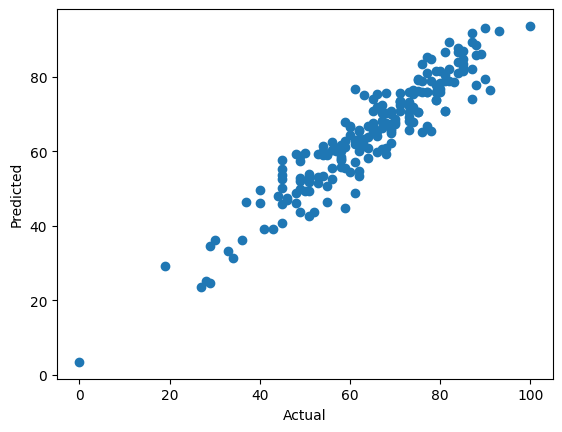

In [22]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

**What this cell does:** Overlays a regression line on the actual-vs-predicted values using `sns.regplot` (with no confidence interval band), giving a clearer visual read on the linear relationship and any systematic bias between predictions and actuals.

ci in sns.regplot() controls the confidence interval band drawn around the fitted regression line.

By default, regplot fits a line (or curve) through the scatter points and shades a translucent band around it representing the confidence interval of that fit (default is a 95% CI, computed via bootstrapping).

ci=None — as used in this cell — disables that shaded band entirely, so you just get the clean regression line with no uncertainty shading around it.

If you set ci=95 (or any number 0–100), it draws a band representing that confidence level — e.g., ci=99 gives a wider band (more confident interval), ci=68 a narrower one.

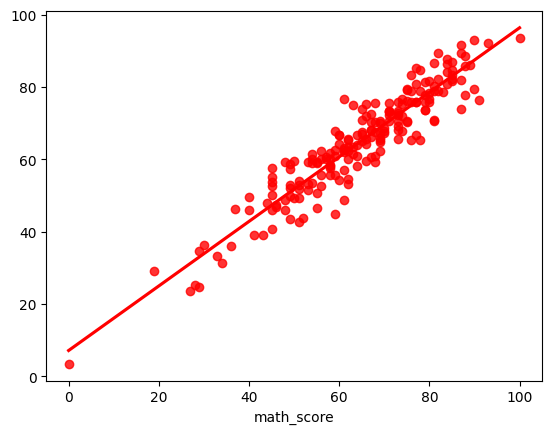

In [23]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

shaded band

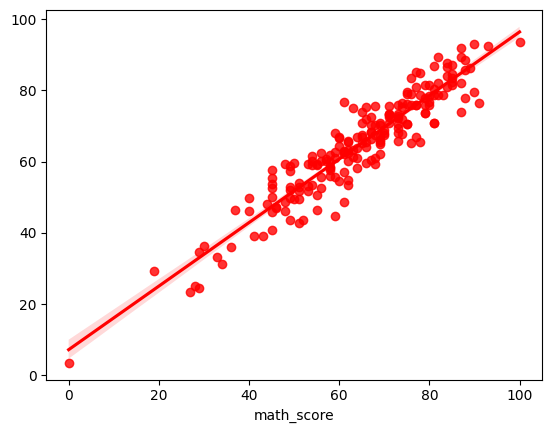

In [24]:
sns.regplot(x=y_test,y=y_pred,ci=90,color ='red');

#### Difference between Actual and Predicted Values

**What this cell does:** Builds a DataFrame `pred_df` that lines up each test sample's actual value, predicted value, and the difference between them, making it easy to inspect individual prediction errors rather than just aggregate metrics.

In [25]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.4375,14.5625
737,53,59.3125,-6.3125
740,80,76.6250,3.3750
660,74,76.5625,-2.5625
411,84,87.7500,-3.7500
...,...,...,...
408,52,43.6875,8.3125
332,62,62.3125,-0.3125
208,74,67.7500,6.2500
613,65,67.0000,-2.0000


## Test the Model with a New Sample

**What this cell does:** Builds a single-row DataFrame representing a brand-new student (with the same 7 feature columns used to train the model: `gender`, `race_ethnicity`, `parental_level_of_education`, `lunch`, `test_preparation_course`, `reading_score`, `writing_score`). It then passes this new record through the already-fitted `preprocessor` (using `.transform`, not `.fit_transform`, since the encoder/scaler must reuse the categories and scaling parameters learned from the training data) and feeds the transformed features into `lin_model.predict()` to get a predicted math score for this hypothetical student.

This demonstrates how the trained pipeline would be used in production: raw new input in, `preprocessor.transform` -> `model.predict`, predicted score out — without ever needing to know the underlying model internals.

In [ ]:
# Sample new student record to test the trained model
new_data = pd.DataFrame({
    'gender': ['female'],
    'race_ethnicity': ['group B'],
    'parental_level_of_education': ["bachelor's degree"],
    'lunch': ['standard'],
    'test_preparation_course': ['completed'],
    'reading_score': [72],
    'writing_score': [74]
})

new_data_transformed = preprocessor.transform(new_data)
predicted_math_score = lin_model.predict(new_data_transformed)
print(f"Predicted Math Score: {predicted_math_score[0]:.2f}")

Predicted Math Score: 63.12


: 